# Waste Collection Messages — Text-CNN Classifier

This notebook implements a full ML pipeline (data load → preprocess → Dataset/Dataloader → Text-CNN model → training → evaluation → inference) using PyTorch.

Goal: classify messages into one of five categories:

- MissedCollection
- ServiceComplaint
- DamagedProperty
- PositiveFeedback
- GeneralInquiry

Run the cells sequentially. Use the CPU or GPU (if available).

In [3]:
# Imports and setup
import os
import re
import random
from collections import Counter

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# file paths
DATA_DIR = os.path.join(os.getcwd(), 'data')
TRAIN_CSV = os.path.join(DATA_DIR, 'AI_Portfolio_Task1_Train.csv')
TEST_CSV = os.path.join(DATA_DIR, 'AI_Portfolio_Task1_Test.csv')

# load train csv
df = pd.read_csv(TRAIN_CSV)
df = df.dropna(subset=['message', 'label']).reset_index(drop=True)
print('Loaded', len(df), 'rows')
print(df.label.value_counts())

# quick text cleaning
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s']", ' ', text)
    text = re.sub(r"\s+", ' ', text).strip()
    return text

df['text'] = df['message'].astype(str).apply(clean_text)

# map labels to indices
labels = sorted(df['label'].unique())
label2idx = {l:i for i,l in enumerate(labels)}
idx2label = {i:l for l,i in label2idx.items()}
print('Labels:', labels)

# train/val split
train_df, val_df = train_test_split(df, test_size=0.15, random_state=SEED, stratify=df['label'])
print('Train:', len(train_df), 'Val:', len(val_df))

# build vocabulary from training data
counter = Counter()
for t in train_df['text']:
    counter.update(t.split())

# keep words with freq >=2
min_freq = 2
vocab = {w for w,f in counter.items() if f >= min_freq}
print('Vocab size (filtered):', len(vocab))

# special tokens
PAD_TOKEN = '<pad>'
UNK_TOKEN = '<unk>'

itos = [PAD_TOKEN, UNK_TOKEN] + sorted(vocab)
stoi = {s:i for i,s in enumerate(itos)}

vocab_size = len(itos)
print('Final vocab size:', vocab_size)

# helper to encode
def encode(text, max_len=100):
    toks = text.split()
    ids = [stoi.get(t, stoi[UNK_TOKEN]) for t in toks][:max_len]
    if len(ids) < max_len:
        ids = ids + [stoi[PAD_TOKEN]] * (max_len - len(ids))
    return ids

MAX_LEN = 100

# apply encoding
train_df['input_ids'] = train_df['text'].apply(lambda t: encode(t, MAX_LEN))
val_df['input_ids'] = val_df['text'].apply(lambda t: encode(t, MAX_LEN))

# create dataset class and collate
class TextDataset(Dataset):
    def __init__(self, df):
        self.inputs = df['input_ids'].tolist()
        self.labels = [label2idx[l] for l in df['label'].tolist()]
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return torch.tensor(self.inputs[idx], dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)

train_ds = TextDataset(train_df)
val_ds = TextDataset(val_df)

BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)

print('Prepared DataLoaders')

Device: cuda:1
Loaded 2119 rows
label
MissedCollection    578
ServiceComplaint    491
DamagedProperty     395
GeneralInquiry      369
PositiveFeedback    286
Name: count, dtype: int64
Labels: ['DamagedProperty', 'GeneralInquiry', 'MissedCollection', 'PositiveFeedback', 'ServiceComplaint']
Train: 1801 Val: 318
Vocab size (filtered): 1746
Final vocab size: 1748
Prepared DataLoaders


TextCNN(
  (embedding): Embedding(1748, 128, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(128, 100, kernel_size=(3,), stride=(1,))
    (1): Conv1d(128, 100, kernel_size=(4,), stride=(1,))
    (2): Conv1d(128, 100, kernel_size=(5,), stride=(1,))
  )
  (dropout): Dropout(p=0.6, inplace=False)
  (fc): Linear(in_features=300, out_features=5, bias=True)
)
Epoch 01: train_loss=1.5184, train_acc=0.3637 | val_loss=1.0973, val_acc=0.5912
Saved best model
Epoch 02: train_loss=0.9616, train_acc=0.6563 | val_loss=0.8234, val_acc=0.7704
Saved best model
Epoch 03: train_loss=0.7083, train_acc=0.7629 | val_loss=0.6616, val_acc=0.8082
Saved best model
Epoch 04: train_loss=0.5287, train_acc=0.8251 | val_loss=0.5577, val_acc=0.8428
Saved best model
Epoch 05: train_loss=0.4311, train_acc=0.8695 | val_loss=0.5244, val_acc=0.8396
Epoch 06: train_loss=0.3472, train_acc=0.8973 | val_loss=0.4915, val_acc=0.8365
Epoch 07: train_loss=0.2974, train_acc=0.9150 | val_loss=0.4294, val_acc=0.8585
Saved best

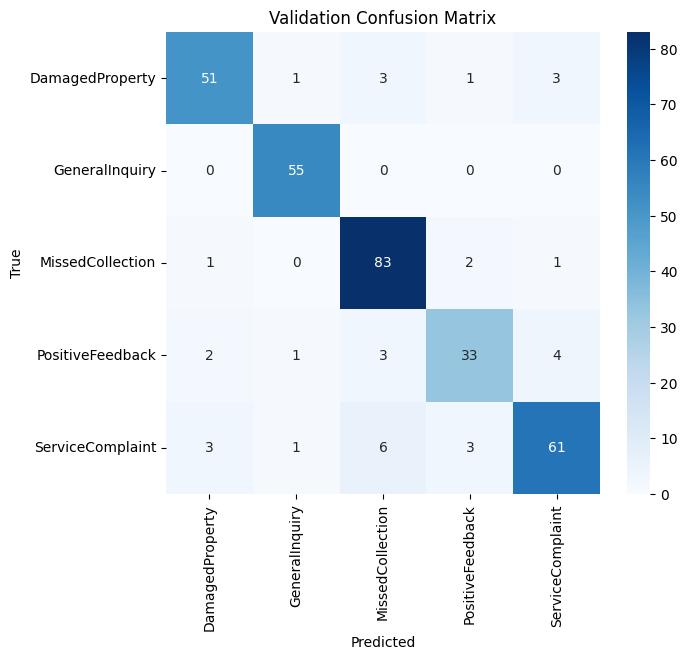

In [4]:
# Text-CNN model
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, num_classes=5, kernel_sizes=[3,4,5], num_filters=100, dropout=0.5, padding_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=padding_idx)
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embed_dim, out_channels=num_filters, kernel_size=k)
            for k in kernel_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def forward(self, x):
        # x: (batch, seq_len)
        emb = self.embedding(x)  # (batch, seq_len, embed_dim)
        emb = emb.permute(0,2,1)  # (batch, embed_dim, seq_len)
        conv_outs = [torch.relu(conv(emb)) for conv in self.convs]
        pooled = [torch.max(co, dim=2)[0] for co in conv_outs]
        cat = torch.cat(pooled, dim=1)
        out = self.dropout(cat)
        logits = self.fc(out)
        return logits

# ...existing code...

# set dropout and early stopping hyperparams
DROPOUT = 0.6          # adjust to increase/decrease regularization
PATIENCE = 20           # stop if no improvement on val_acc for this many epochs
MIN_DELTA = 1e-4       # minimum improvement to reset patience

# Create model with dropout passed in
model = TextCNN(vocab_size=vocab_size, embed_dim=128, num_classes=len(labels), dropout=DROPOUT).to(device)
print(model)

# training utilities
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

from tqdm.notebook import tqdm

# simple EarlyStopping helper
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.num_bad_epochs = 0
        self.best_state = None

    def step(self, score, model):
        # higher score is better
        if self.best_score is None or (score - self.best_score) > self.min_delta:
            self.best_score = score
            self.num_bad_epochs = 0
            # keep a copy of best model state_dict
            self.best_state = {k:v.cpu().clone() for k,v in model.state_dict().items()}
            return False  # don't stop
        else:
            self.num_bad_epochs += 1
            if self.num_bad_epochs >= self.patience:
                return True   # should stop
            return False

    def load_best(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += xb.size(0)
    return total_loss/total, correct/total

def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += xb.size(0)
            all_preds.extend(preds.cpu().numpy().tolist())
            all_labels.extend(yb.cpu().numpy().tolist())
    return total_loss/total, correct/total, all_preds, all_labels

# training loop with early stopping
EPOCHS = 1000
best_val = 0.0
early_stopper = EarlyStopping(patience=PATIENCE, min_delta=MIN_DELTA)

for epoch in range(1, EPOCHS+1):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, _, _ = eval_epoch(model, val_loader, criterion, device)
    print(f"Epoch {epoch:02d}: train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")
    # save checkpoint on improvement
    if val_acc > best_val + MIN_DELTA:
        best_val = val_acc
        torch.save({
            'model_state': model.state_dict(),
            'stoi': stoi,
            'itos': itos,
            'label2idx': label2idx,
            'idx2label': idx2label,
            'max_len': MAX_LEN
        }, os.path.join(DATA_DIR, 'text_cnn_checkpoint.pth'))
        print('Saved best model')
    # early stopping decision (monitors val_acc)
    should_stop = early_stopper.step(val_acc, model)
    if should_stop:
        print(f"Early stopping triggered (no val_acc improvement for {PATIENCE} epochs).")
        break

# after training, restore best weights from early_stopper if available
early_stopper.load_best(model)

# evaluation on validation set with report (final)
val_loss, val_acc, val_preds, val_labels = eval_epoch(model, val_loader, criterion, device)
print('Val acc:', val_acc)
print(classification_report(val_labels, val_preds, target_names=labels))

# confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(val_labels, val_preds)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Validation Confusion Matrix')
plt.show()

In [5]:
# Inference helpers
ckpt_path = os.path.join(DATA_DIR, 'text_cnn_checkpoint.pth')
ckpt = torch.load(ckpt_path, map_location=device)

# reload model/metadata
model = TextCNN(vocab_size=len(ckpt['itos']), embed_dim=128, num_classes=len(ckpt['idx2label'])).to(device)
model.load_state_dict(ckpt['model_state'])
model.eval()
itos = ckpt['itos']
stoi = {s:i for i,s in enumerate(itos)}
idx2label = ckpt['idx2label']
MAX_LEN = ckpt.get('max_len', 100)


def preprocess_and_encode(text):
    t = clean_text(text)
    toks = t.split()
    ids = [stoi.get(w, stoi[UNK_TOKEN]) for w in toks][:MAX_LEN]
    if len(ids) < MAX_LEN:
        ids = ids + [stoi[PAD_TOKEN]] * (MAX_LEN - len(ids))
    return torch.tensor([ids], dtype=torch.long)


def predict(text):
    xb = preprocess_and_encode(text).to(device)
    with torch.no_grad():
        logits = model(xb)
        p = torch.softmax(logits, dim=1)[0]
        pred = p.argmax().item()
        # idx2label uses integer keys, so use the integer `pred` directly
        return idx2label[pred], p[pred].item()

# demo
examples = [
    "My bin wasn't emptied today and it's overflowing",
    "Your driver broke my gate during collection",
    "Love the service — drivers are always friendly!",
    "Do you collect batteries?",
    "The crew left my bin on the pavement blocking the path"
]

for ex in examples:
    label, score = predict(ex)
    print(f"{ex} -> {label} (conf={score:.2f})")

My bin wasn't emptied today and it's overflowing -> MissedCollection (conf=0.99)
Your driver broke my gate during collection -> DamagedProperty (conf=0.99)
Love the service — drivers are always friendly! -> PositiveFeedback (conf=0.97)
Do you collect batteries? -> GeneralInquiry (conf=1.00)
The crew left my bin on the pavement blocking the path -> ServiceComplaint (conf=0.99)
